<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/Lab4_Photoelectric_effect_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.constants import h, elementary_charge as e, speed_of_light as c

# Picoammeter digital and analogue readings comparison

On the back side of the picoammeter there are sockets for digital measurements. Let's see how they are aligned with analogue readings, both on x100 range and x30 range. We change light intensity using variac and write down readings of the picoammeter.



Text(0, 0.5, 'Current readings, pA')

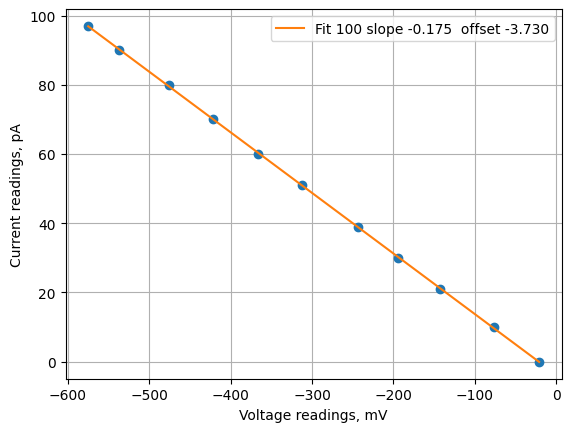

In [2]:
data100 = '''
# after justifying zero
#-1 -004 # dark
0 -021
10 -077
21 -143
30 -194
39 -243
51 -312
60 -366
70 -422
80 -476
90 -537
97 -575
'''

I100, V100 = np.genfromtxt(data100.splitlines()).T
plt.plot(V100, I100, 'o')

fit100 = linregress(V100, I100)
plt.plot(V100, fit100.intercept + fit100.slope * V100, \
         color='C1', label=f'Fit 100 slope {fit100.slope:.3f}  offset {fit100.intercept:.3f}')
plt.grid()
plt.legend()
plt.xlabel('Voltage readings, mV')
plt.ylabel('Current readings, pA')

In [3]:
# function converting voltage readings to current readings
def V2I(V, order, divider=100):
  # order -12: pA, -11: x10  pA, -10: x100 pA
  # divider = 100 (scale x100) or 30 (scale x30)
  return ( fit100.slope * V) * divider / 100 * 10**order

# example
# picoammeter in scale 10^-12 divider 30
V = -4
print(f' Reading {V} mV, current {V2I(V, -12, 30)*1e12:.2f} pA')

 Reading -4 mV, current 0.21 pA


#Volt-ampere curve


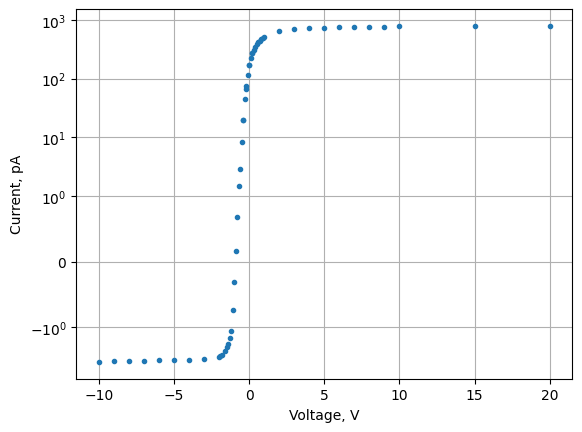

In [48]:
# green diode 525 filter 3 500 nm
# light intensity 0.8uW before filter
I = np.array([])
V = np.array([])

data = '''
# V/V Va/mV order, divider
-10 -75 -12 30
-9 -72 -12 30
-8 -71 -12 30
-7 -71 -12 30
-6 -70 -12 30
-5 -70 -12 30
-4 -69 -12 30
-3 -68 -12 30
-2 -61 -12 30
-1.9 -59 -12 30
-1.8 -57 -12 30
-1.7 -52 -12 3-
-1.6 -48 -12 30
-1.5 -42 -12 30
-1.4 -37 -12 30
-1.3 -29 -12 30
-1.2 -22 -12 30
-1.1 -14 -12 30
-1.0 -6 -12 30
-0.9 +3 -12 30 # changed polarity on picoammeter
-0.8 13 -12 30
-0.7 28 -12 30
-0.6 56 -12 30
-0.5 157 -12 30
-0.4 376 -12 30
-0.4 113 -12 100
-0.3 256 -12 100
-0.2 427 -12 100
-0.2 126 -11 30  # order -10 on picoammeter = true order -11
-0.1 222 -11 30
0.0 322 -11 30
0.0 323 -11 30 # changed power supply polarity
0.1 421 -11 30
0.2 518 -11 30
0.2 155 -11 100
0.3 176 -11 100
0.4 200 -11 100
0.5 218 -11 100
0.6 237 -11 100
0.7 252 -11 100
0.8 268 -11 100
0.9 280 -11 100
1.0 292 -11 100
2. 369 -11 100
3. 402 -11 100
4 415 -11 100
5 423 -11 100
6 428 -11 100
7 432 -11 100
8 436 -11 100
9 440 -11 100
10 444 -11 100
15 451 -11 100
20 449 -11 100
'''
V, Va, order, divider = np.genfromtxt(data.splitlines()).T
I = V2I(-Va, order, divider)


plt.plot(V, I*1e12, '.')
plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, pA')
plt.grid()
#plt.xlim(-2, 1)

# Va readings[mV] V[V]

def find_roots(x, y):
    roots = []
    for i in range(len(y) - 1):
        if y[i] * y[i+1] <= 0:  # Check for a sign change
            # Linear interpolation: x = x1 + (0 - y1) * (x2 - x1) / (y2 - y1)
            root = x[i] - y[i] * (x[i+1] - x[i]) / (y[i+1] - y[i])
            roots.append(root)
    return roots

#V0 = find_roots(V, I)[0]
#plt.plot(V0, 0, 'o', color='red')
#plt.annotate(f'V0 = {V0:.2f} V', (V0, 0))

(-2.0, 1.0)

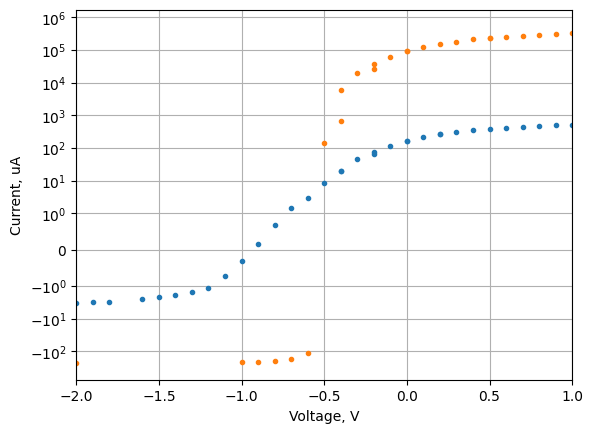

In [51]:
# green diode 525 filter 3 500 nm
# light intensity 9uW before filter

data = '''
# V/V Va/mV order, divider
20 271 -8 100 # order 8 as written on picoammeter
15 272 -8 100
10 267 -8 100
9 290 -8 100
8 290 -8 100
7 285 -8 100
6 290 -8 100
5 277 -8 100
4 280 -8 100
3 280 -8 100
2 260 -8 100
1 187 -8 100
.9 177 -8 100
.8 168 -8 100
.7 156 -8 100
.6 145 -8 100
.5 131 -8 100
.5 441 -8 30
.4 400 -8 30
.3 346 -8 30
.2 300 -8 30
.1 240 -8 30
0 180 -8 30 # change power supply polarity
0 178 -8 30
-.1 114 -8 30
-.2 50 -8 30
-.2 213 -9 100
-.3 109 -9 100
-.4 33 -9 100
-.4 383 -11 100
-.5 80 -11 100
-.6 -62 -11 100 # change polarity on picoampermeter
-.7 -99 -11 100
-.8 -113 -11 100
-.9 -118 -11 100
-1 -120 -11 100
-2 -128 -11 100
-3 -128 -11 100
-4 -129 -11 100
-5 -129 -11 100
-6 -129 -11 100
-7 -129 -11 100
-8 -129 -11 100
-9 -129 -11 100
-10 -129 -11 100
'''
V2, V2a, order, divider = np.genfromtxt(data.splitlines()).T
I2 = V2I(-V2a, order, divider)


plt.plot(V, I*1e12, '.')
plt.plot(V2, I2*1e12, '.')

plt.yscale('symlog', linthresh=1)
plt.xlabel('Voltage, V')
plt.ylabel('Current, uA')
plt.grid()
plt.xlim(-2, 1)




# Plank's constant and Work potential determination

$$
\frac{h}{e} \nu = V_0(\nu) +  W
$$

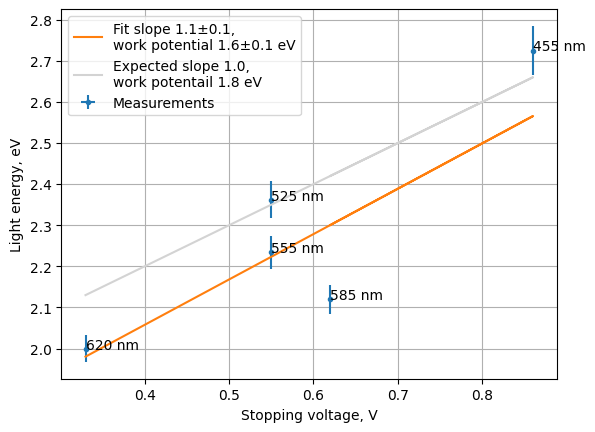

In [52]:
data = '''
585 0.62
455 0.86
#500 0.67
525 0.55
555 0.55
620 0.33
'''

def linear(voltage, slope, offset):
    return slope * voltage + offset


wl, V0 = np.genfromtxt(data.splitlines()).T

wl, V0 = np.genfromtxt(data.splitlines()).T

relative_error = 10 / wl # error 10 nm

wl *= 1e-9
nu = c / wl
energy = h * nu / e # eV
energy_err = energy * relative_error
V_err = 2e-3 # V

# curve fit takes into account weights of uncertainties
# so it is more accurate than linregress calculates slope and offset

popt, pcov = curve_fit(linear, V0, energy, sigma=energy_err, absolute_sigma=True)
slope = popt[0]
offset = popt[1]
errs = np.sqrt(np.diag(pcov))
slope_err = errs[0]
offset_err = errs[1]
offset_expected = 1.8 # for Cs-Sb Photocathode
plt.errorbar(V0, energy, yerr=energy_err, xerr=V_err, ls='', marker='.', label='Measurements')
plt.plot(V0, offset + slope * V0, label=f'Fit slope {slope:.1f}±{slope_err:.1f},\nwork potential {offset:.1f}±{offset_err:.1f} eV')
plt.plot(V0, offset_expected +  V0, color='lightgray', label=f'Expected slope 1.0,\nwork potentail {offset_expected:.1f} eV')

for i in range(len(V0)):
    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel('Stopping voltage, V')
plt.ylabel('Light energy, eV')
#plt.xlim(0.2, 1)
plt.show()

